## Operator Benchmarks

Each row checks forward and backward correctness against `TorchOpsBackend`, then reports forward/backward p50 latency, p95 latency, peak CUDA memory delta, and speedup versus torch.


In [1]:
from pathlib import Path
import sys

import torch

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "minitrain").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

sys.path.insert(0, str(PROJECT_ROOT))
sys.path.insert(0, str(PROJECT_ROOT / "tests"))

from minitrain.model.ops import get_ops_backend
from operator_nsight import nsight_kernel, register_nsight_kernel
from operator_bench_utils import (
    BenchCase,
    bench_sweep,
    collect_triton_best_configs,
    display_triton_config_summary,
    plot_kernel_grid,
    to_summary_dataframe,
)

torch.manual_seed(0)
assert torch.cuda.is_available(), "operator benchmarks require CUDA"

DEVICE = torch.device("cuda")
DTYPE = torch.float16
PROVIDERS = ("torch", "triton", "cuda")
WARMUP_MS = 25
REP_MS = 100
FIG_DIR = PROJECT_ROOT / "reports" / "figures"
METRICS = (
    "fwd_p50_ms",
    "fwd_p95_ms",
    "fwd_peak_mem_mb",
    "fwd_speedup",
    "bwd_p50_ms",
    "bwd_p95_ms",
    "bwd_peak_mem_mb",
    "bwd_speedup",
)

print(torch.__version__)
print(torch.cuda.get_device_name(0))


2.5.1+cu121
NVIDIA GeForce RTX 3050 Laptop GPU


Each kernel section now provides `make_case(size)` and `forward(provider, tensors)`. The runner owns tensor cloning, forward/backward correctness, timing, memory measurement, and cleanup. Cleanup clears the torch-created tensor dictionary before releasing the CUDA cache.

Generate a small Nsight Compute report with one line, for example `nsight_kernel("rmsnorm")` or `nsight_kernel("attention", mode="bwd")`. `size` uses the same logical size as the corresponding benchmark when explicitly provided.

In [2]:
def run_kernel(
    kernel,
    sizes,
    size_label,
    make_case,
    forward,
    *,
    autotune_kernels=None,
    nsight_size=None,
):
    sizes = tuple(sizes)
    register_nsight_kernel(
        kernel,
        make_case,
        forward,
        default_size=min(sizes) if nsight_size is None else nsight_size,
    )
    rows = bench_sweep(
        kernel=kernel,
        providers=PROVIDERS,
        sizes=sizes,
        size_label=size_label,
        make_case=make_case,
        forward=forward,
        warmup_ms=WARMUP_MS,
        rep_ms=REP_MS,
        autotune_kernels=autotune_kernels,
    )
    display(to_summary_dataframe(rows))
    plot_kernel_grid(rows, metrics=METRICS, save_path=FIG_DIR / f"{kernel}_summary.png")
    return rows


## RMSNorm

Sweep parameter: `rows`.

X-axis: activation tensor elements, `rows * hidden`.

,kernel,provider,size,status,fwd_correct,bwd_correct,fwd_max_abs,bwd_max_abs,fwd_p50_ms,fwd_p95_ms,fwd_peak_mem_mb,fwd_speedup,bwd_p50_ms,bwd_p95_ms,bwd_peak_mem_mb,bwd_speedup
0,rmsnorm,torch,16384,ok,True,True,0.000000,0.000000,0.033792,0.034816,0.125000,1.000000,0.601696,1.178685,0.250000,1.000000
1,rmsnorm,triton,16384,ok,True,True,0.001953,0.015625,0.006144,0.006144,0.031738,5.500000,0.342048,0.449280,0.080078,1.759098
2,rmsnorm,torch,32768,ok,True,True,0.000000,0.000000,0.027648,0.029696,0.250000,1.000000,0.592896,1.148366,0.500000,1.000000
3,rmsnorm,triton,32768,ok,True,True,0.001953,0.015625,0.005120,0.006144,0.062988,5.400000,0.376368,0.509910,0.142578,1.575309
4,rmsnorm,torch,65536,ok,True,True,0.000000,0.000000,0.028672,0.030720,0.500000,1.000000,0.541584,1.111806,0.999512,1.000000
5,rmsnorm,triton,65536,ok,True,True,0.003906,0.031250,0.007168,0.008192,0.125977,4.000000,0.410000,0.644198,0.267578,1.320937
6,rmsnorm,torch,131072,ok,True,True,0.000000,0.000000,0.035840,0.037888,1.000000,1.000000,0.535056,1.071229,1.998047,1.000000
7,rmsnorm,triton,131072,ok,True,True,0.003906,0.031250,0.008192,0.009216,0.251953,4.375000,0.351744,0.446720,0.517578,1.521152
8,rmsnorm,torch,262144,ok,True,True,0.000000,0.000000,0.052224,0.054272,2.000000,1.000000,0.573440,0.982923,3.995117,1.000000
9,rmsnorm,triton,262144,ok,True,True,0.001953,0.062500,0.011264,0.011264,0.503906,4.636364,0.397440,0.644352,1.017578,1.442834


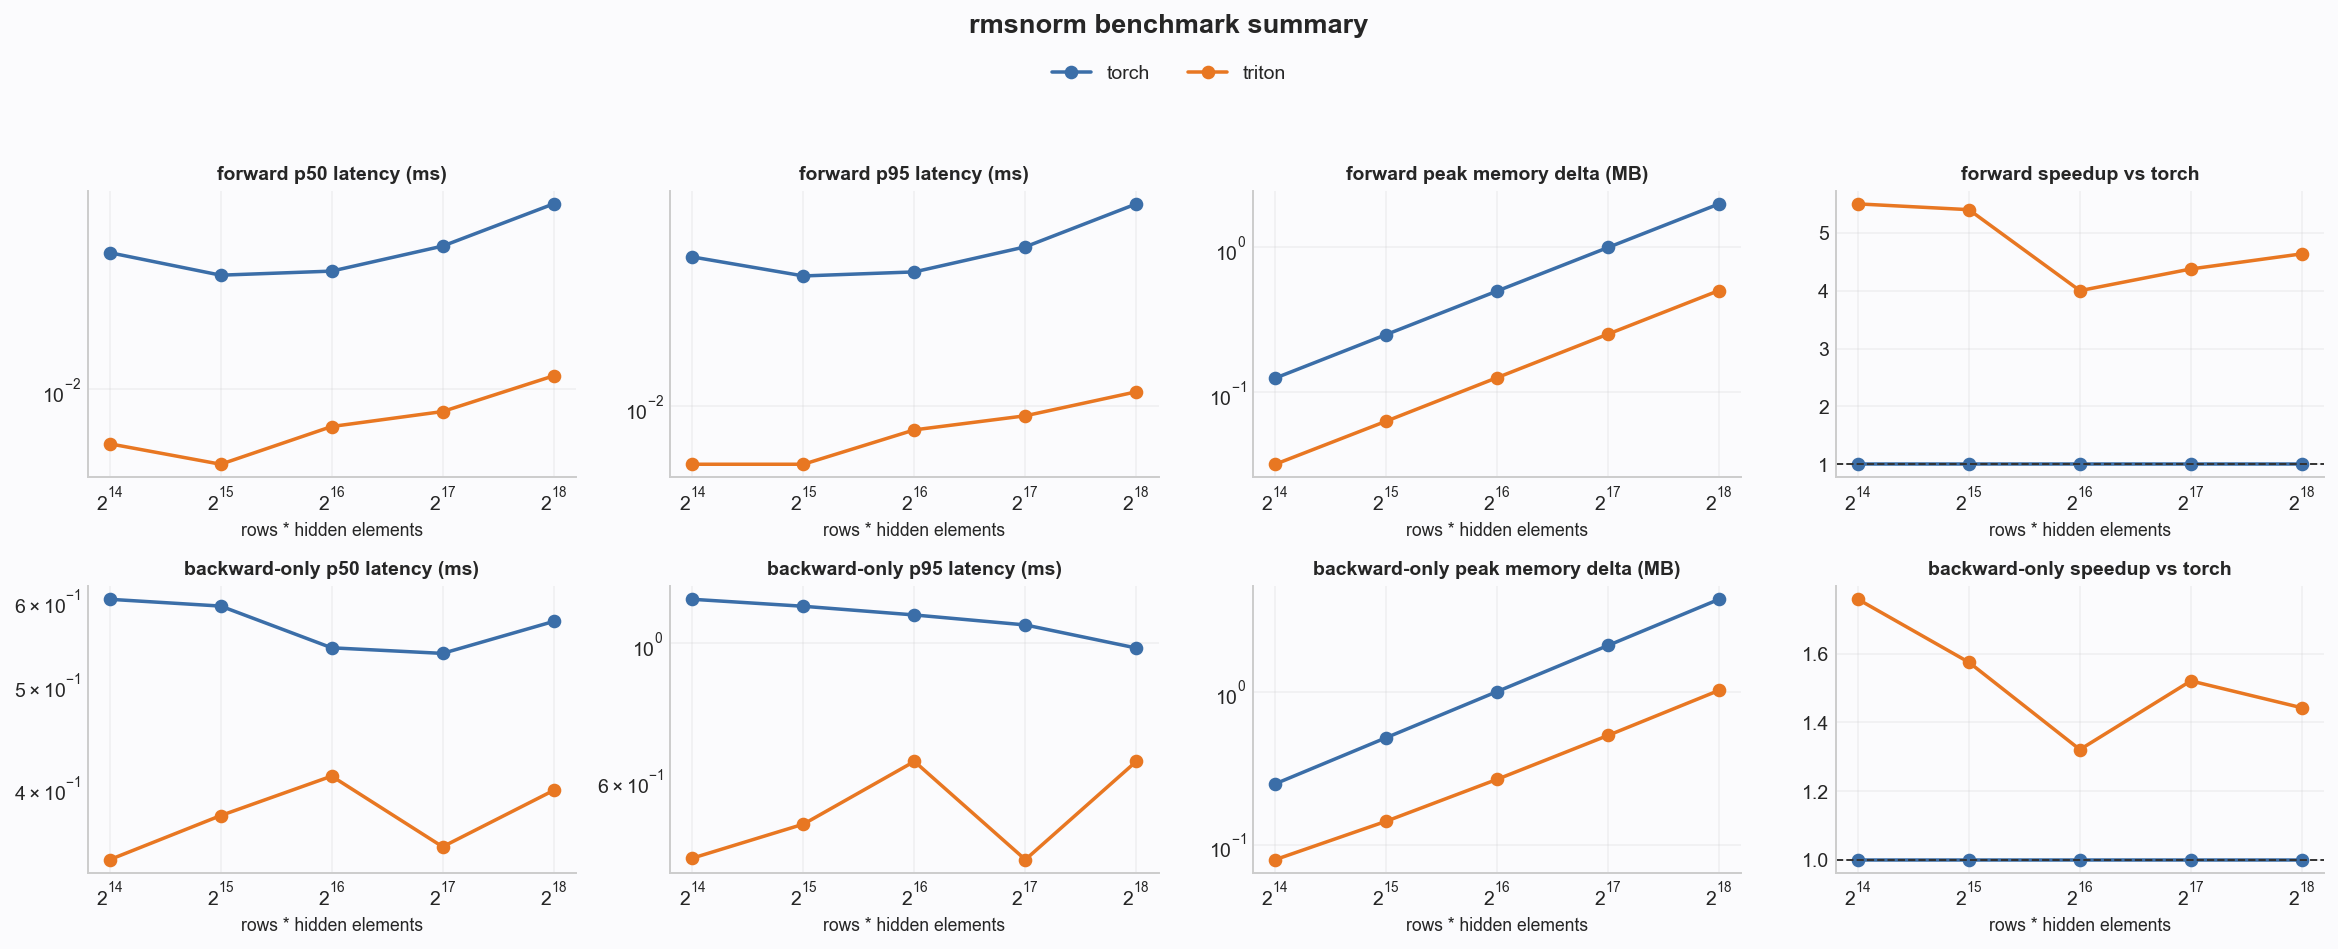

In [3]:
PROVIDERS = ("torch", "triton")
def make_rmsnorm_case(size):
    hidden = 256
    rows = size // hidden
    return BenchCase(
        tensors={
            "x": torch.randn(rows, hidden, device=DEVICE, dtype=DTYPE),
            "weight": torch.ones(hidden, device=DEVICE, dtype=DTYPE),
        },
        grad_names=("x", "weight"),
    )


def rmsnorm_forward(provider, tensors):
    backend = get_ops_backend(provider)
    return backend.rmsnorm(tensors["x"], tensors["weight"], 1e-5)


rmsnorm_sizes = [256 * rows for rows in (64, 128, 256, 512, 1024)]
rmsnorm_rows = run_kernel(
    "rmsnorm",
    rmsnorm_sizes,
    "rows * hidden elements",
    make_rmsnorm_case,
    rmsnorm_forward,
)

## RoPE

Sweep parameter: `seq`.

X-axis: Q+K tensor elements, `2 * batch * heads * seq * head_dim`.

,kernel,provider,size,status,fwd_correct,bwd_correct,fwd_max_abs,bwd_max_abs,fwd_p50_ms,fwd_p95_ms,fwd_peak_mem_mb,fwd_speedup,bwd_p50_ms,bwd_p95_ms,bwd_peak_mem_mb,bwd_speedup
0,rope,torch,16384,ok,True,True,0.000000,0.0,0.096320,0.156544,0.06250,1.000000,0.701968,1.071720,0.078613,1.000000
1,rope,triton,16384,ok,True,True,0.001953,0.0,0.005120,0.006144,0.03125,18.812501,0.406464,0.475443,0.062988,1.727011
2,rope,torch,32768,ok,True,True,0.000000,0.0,0.109568,0.158720,0.12500,1.000000,0.628736,0.975104,0.156738,1.000000
3,rope,triton,32768,ok,True,True,0.001953,0.0,0.006144,0.008090,0.06250,17.833333,0.431568,0.523878,0.125488,1.456864
4,rope,torch,65536,ok,True,True,0.000000,0.0,0.094208,0.126464,0.25000,1.000000,0.581680,0.622694,0.312988,1.000000
5,rope,triton,65536,ok,True,True,0.001953,0.0,0.006144,0.007168,0.12500,15.333333,0.349696,0.378880,0.250488,1.663388
6,rope,torch,131072,ok,True,True,0.000000,0.0,0.089088,0.129024,0.50000,1.000000,0.581184,0.669850,0.625488,1.000000
7,rope,triton,131072,ok,True,True,0.003906,0.0,0.008192,0.009216,0.25000,10.875000,0.348672,0.387226,0.500488,1.666850
8,rope,torch,262144,ok,True,True,0.000000,0.0,0.086528,0.130390,1.00000,1.000000,0.588240,0.777472,1.250488,1.000000
9,rope,triton,262144,ok,True,True,0.001953,0.0,0.011264,0.012288,0.50000,7.681818,0.354304,0.488642,1.000488,1.660269


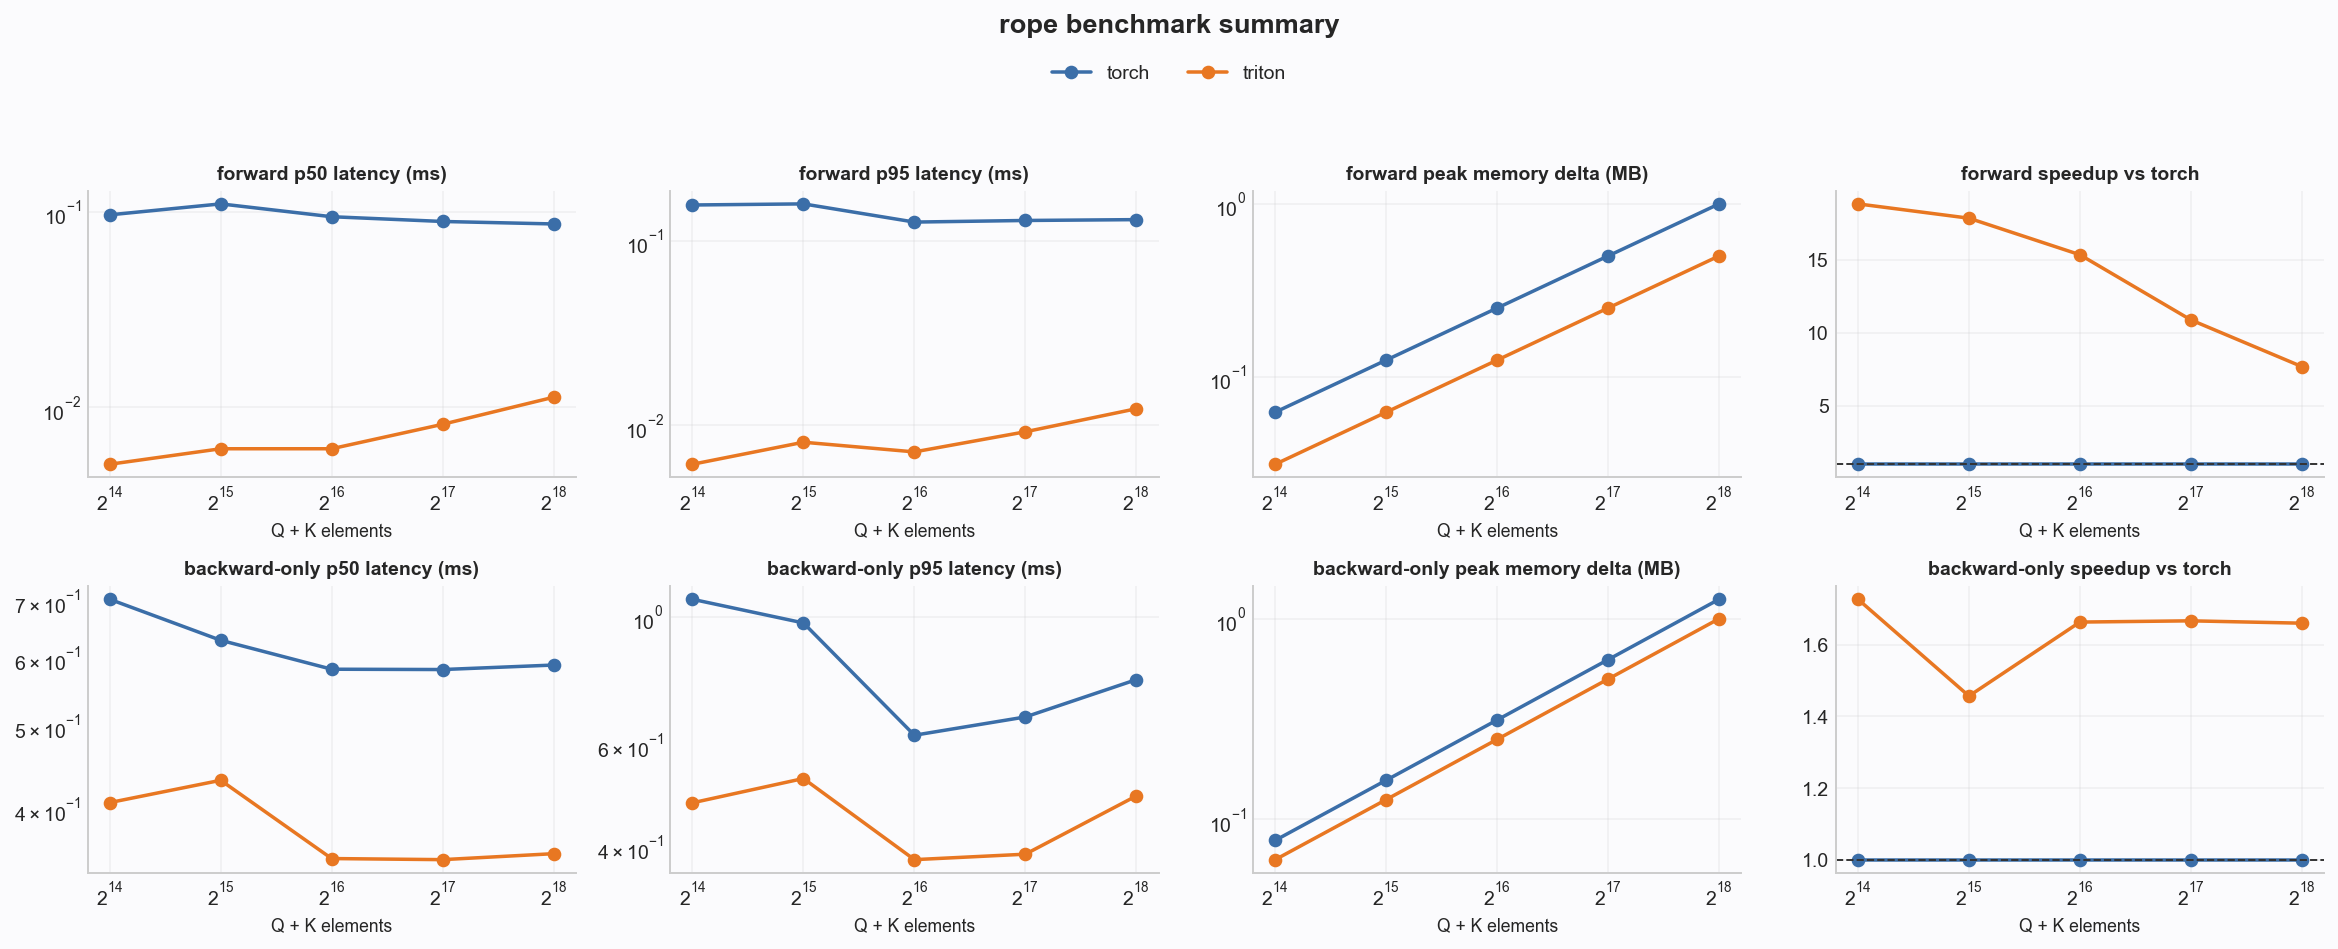

In [4]:
PROVIDERS = ("torch", "triton")
def rope_cache(seq, dim):
    inv_freq = 1.0 / (10000 ** (torch.arange(0, dim, 2, device=DEVICE).float() / dim))
    freqs = torch.outer(torch.arange(seq, device=DEVICE).float(), inv_freq)
    emb = torch.cat((freqs, freqs), dim=-1)
    return emb.cos().to(dtype=DTYPE), emb.sin().to(dtype=DTYPE)


def make_rope_case(size):
    batch, heads, head_dim = 1, 4, 64
    seq = size // (2 * batch * heads * head_dim)
    cos, sin = rope_cache(seq, head_dim)
    return BenchCase(
        tensors={
            "q": torch.randn(batch, heads, seq, head_dim, device=DEVICE, dtype=DTYPE),
            "k": torch.randn(batch, heads, seq, head_dim, device=DEVICE, dtype=DTYPE),
            "cos": cos,
            "sin": sin,
        },
        grad_names=("q", "k"),
    )


def rope_forward(provider, tensors):
    backend = get_ops_backend(provider)
    return backend.rope(tensors["q"], tensors["k"], tensors["cos"], tensors["sin"])


rope_sizes = [2 * 1 * 4 * seq * 64 for seq in (32, 64, 128, 256, 512)]
rope_rows = run_kernel("rope", rope_sizes, "Q + K elements", make_rope_case, rope_forward)


## SwiGLU

Sweep parameter: `rows`.

X-axis: input tensor elements, `2 * rows * intermediate` for gate and up.

,kernel,provider,size,status,fwd_correct,bwd_correct,fwd_max_abs,bwd_max_abs,fwd_p50_ms,fwd_p95_ms,fwd_peak_mem_mb,fwd_speedup,bwd_p50_ms,bwd_p95_ms,bwd_peak_mem_mb,bwd_speedup
0,swiglu,torch,65536,ok,True,True,0.000000,0.000000,0.010240,0.011264,0.1250,1.000000,0.222800,0.292301,0.187988,1.000000
1,swiglu,triton,65536,ok,True,True,0.000000,0.000977,0.006144,0.007168,0.0625,1.666667,0.321024,0.350232,0.187988,0.694029
2,swiglu,torch,131072,ok,True,True,0.000000,0.000000,0.010240,0.011264,0.2500,1.000000,0.236608,0.272538,0.375488,1.000000
3,swiglu,triton,131072,ok,True,True,0.000244,0.000488,0.007168,0.007894,0.1250,1.428571,0.278048,0.337050,0.375488,0.850961
4,swiglu,torch,262144,ok,True,True,0.000000,0.000000,0.012304,0.014336,0.5000,1.000000,0.212464,0.247245,0.750488,1.000000
5,swiglu,triton,262144,ok,True,True,0.000122,0.000488,0.009216,0.009230,0.2500,1.335069,0.407552,0.703747,0.750488,0.521318
6,swiglu,torch,524288,ok,True,True,0.000000,0.000000,0.018432,0.019456,1.0000,1.000000,0.234496,0.291891,1.500488,1.000000
7,swiglu,triton,524288,ok,True,True,0.000244,0.001953,0.013312,0.014336,0.5000,1.384615,0.303616,0.375296,1.500488,0.772344
8,swiglu,torch,1048576,ok,True,True,0.000000,0.000000,0.033792,0.035840,2.0000,1.000000,0.209376,0.279597,3.000488,1.000000
9,swiglu,triton,1048576,ok,True,True,0.000244,0.000977,0.022528,0.022960,1.0000,1.500000,0.257552,0.351840,3.000488,0.812946


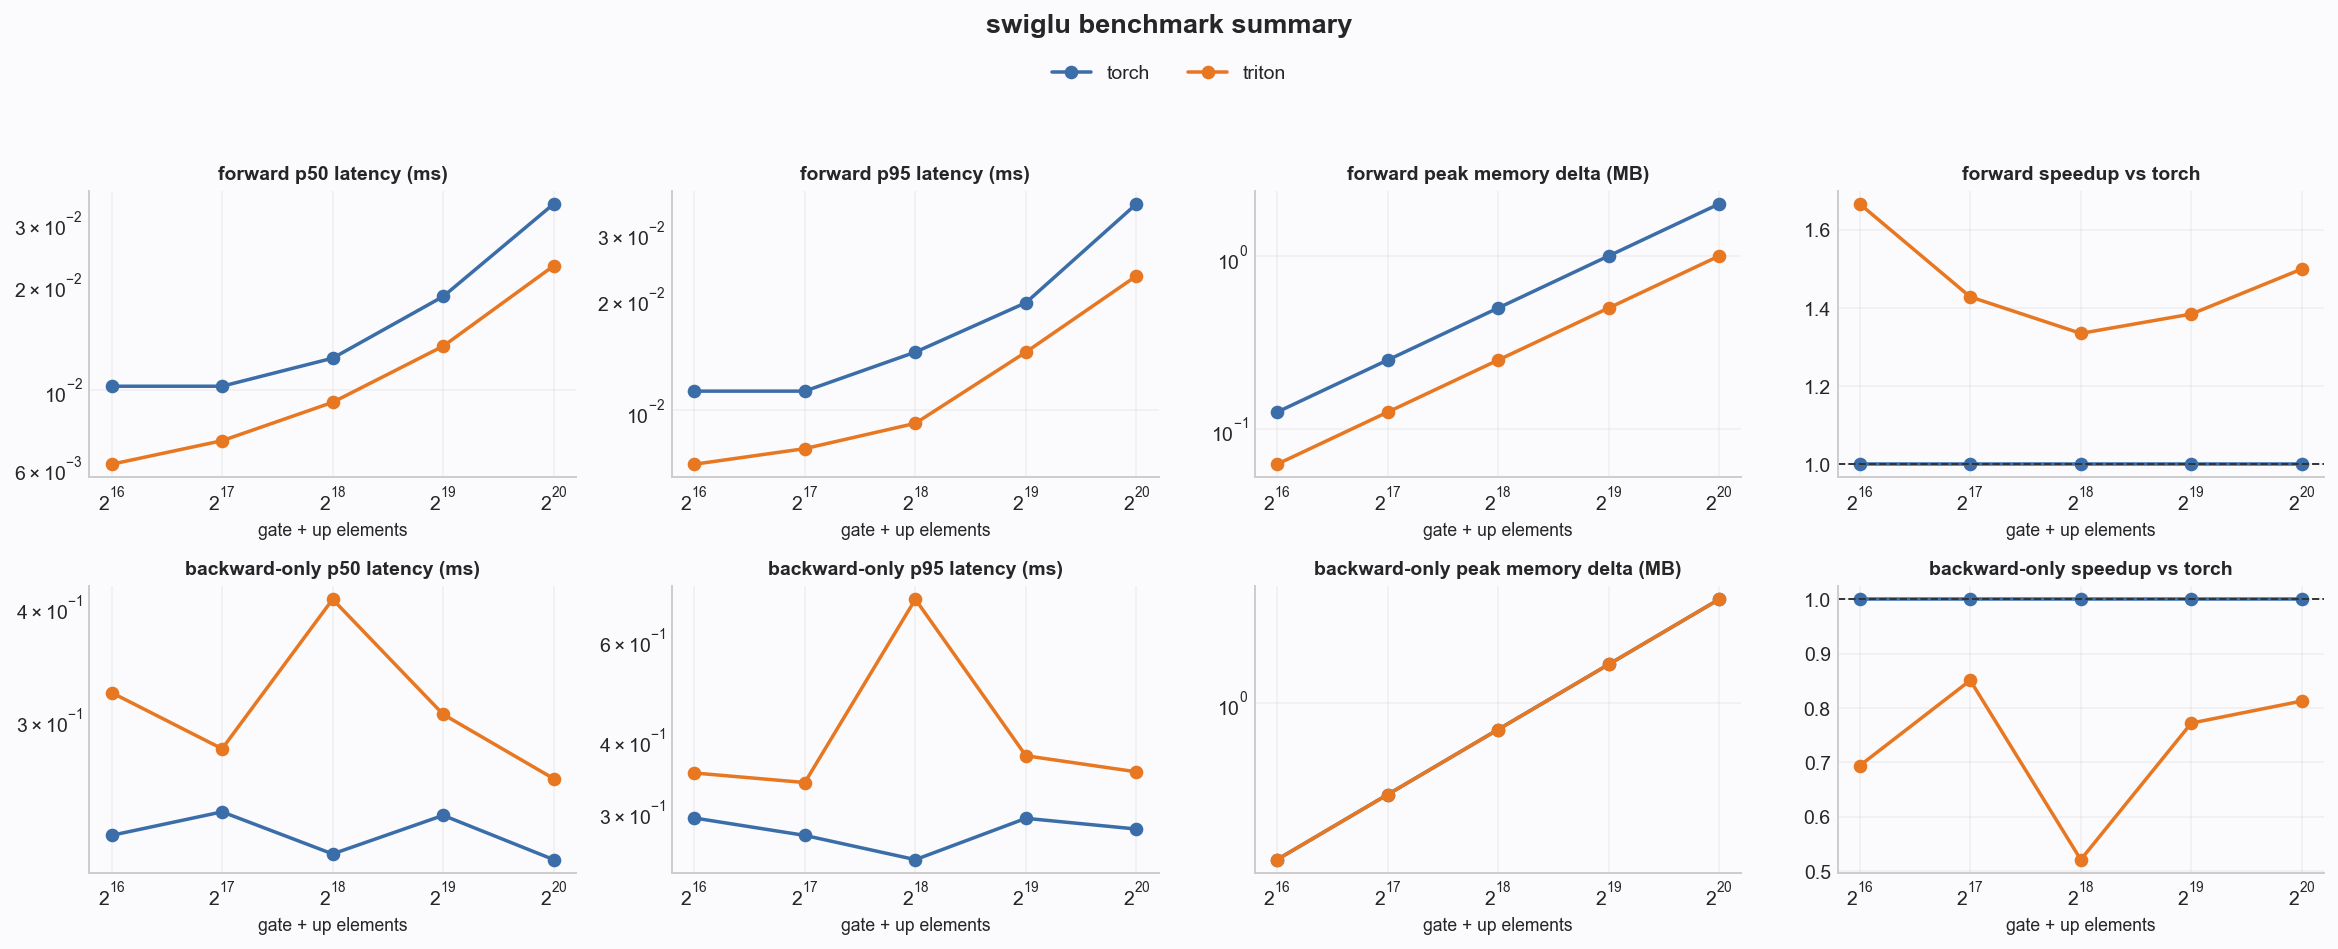

In [6]:
PROVIDERS = ("torch", "triton")
def make_swiglu_case(size):
    intermediate = 512
    rows = size // (2 * intermediate)
    return BenchCase(
        tensors={
            "gate": torch.randn(rows, intermediate, device=DEVICE, dtype=DTYPE),
            "up": torch.randn(rows, intermediate, device=DEVICE, dtype=DTYPE),
        },
        grad_names=("gate", "up"),
    )


def swiglu_forward(provider, tensors):
    backend = get_ops_backend(provider)
    return backend.swiglu(tensors["gate"], tensors["up"])


swiglu_sizes = [2 * rows * 512 for rows in (64, 128, 256, 512, 1024)]
swiglu_rows = run_kernel(
    "swiglu",
    swiglu_sizes,
    "gate + up elements",
    make_swiglu_case,
    swiglu_forward,
)


## CrossEntropy

Sweep parameter: `tokens`.

X-axis: logits tensor elements, `tokens * vocab`.

In [ ]:
def make_cross_entropy_case(size):
    vocab = 1024
    tokens = size // vocab
    return BenchCase(
        tensors={
            "logits": torch.randn(tokens, vocab, device=DEVICE, dtype=DTYPE),
            "targets": torch.randint(vocab, (tokens,), device=DEVICE),
        },
        grad_names=("logits",),
    )


def cross_entropy_forward(provider, tensors):
    backend = get_ops_backend(provider)
    return backend.cross_entropy(tensors["logits"], tensors["targets"])


cross_entropy_sizes = [tokens * 1024 for tokens in (64, 128, 256, 512, 1024)]
cross_entropy_rows = run_kernel(
    "cross_entropy",
    cross_entropy_sizes,
    "tokens * vocab logits elements",
    make_cross_entropy_case,
    cross_entropy_forward,
)


## FusedLinearCrossEntropy

Sweep parameter: `vocab`.

X-axis: logical logits elements, `tokens * vocab`. This is the tensor a fused implementation tries not to materialize.

In [ ]:
def make_fused_linear_ce_case(size):
    tokens, hidden = 128, 256
    vocab = size // tokens
    return BenchCase(
        tensors={
            "x": torch.randn(tokens, hidden, device=DEVICE, dtype=DTYPE),
            "weight": torch.randn(vocab, hidden, device=DEVICE, dtype=DTYPE),
            "targets": torch.randint(vocab, (tokens,), device=DEVICE),
        },
        grad_names=("x", "weight"),
    )


def fused_linear_ce_forward(provider, tensors):
    backend = get_ops_backend(provider)
    return backend.fused_linear_cross_entropy(tensors["x"], tensors["weight"], tensors["targets"])


fused_linear_ce_sizes = [128 * vocab for vocab in (512, 1024, 2048, 4096, 8192)]
fused_linear_ce_rows = run_kernel(
    "fused_linear_cross_entropy",
    fused_linear_ce_sizes,
    "tokens * vocab logical logits elements",
    make_fused_linear_ce_case,
    fused_linear_ce_forward,
)


## FlashAttention

### FlashAttention (no dropout)

Bench MiniTrain's attention path and print the PyTorch SDPA backend selected for the same benchmark shapes.


PyTorch SDPA backend selection:
  is_causal=True, dropout_p=0.0
  shape=(2, 4, 10, 128) -> memory_efficient_attention
  shape=(2, 4, 40, 128) -> memory_efficient_attention
  shape=(2, 4, 160, 128) -> memory_efficient_attention
  shape=(2, 4, 640, 128) -> memory_efficient_attention


,benchmark,provider,size,size_label,triton_kernel,BLOCK_M,BLOCK_N,num_warps,num_stages,num_ctas
0,attention,triton,30720,Q + K + V elements,flash_attention_forward,64,32,4,3,1
1,attention,triton,30720,Q + K + V elements,flash_attention_backward,128,128,8,1,1
2,attention,triton,122880,Q + K + V elements,flash_attention_forward,64,64,8,3,1
3,attention,triton,122880,Q + K + V elements,flash_attention_backward,128,128,8,1,1
4,attention,triton,491520,Q + K + V elements,flash_attention_forward,128,32,8,3,1
5,attention,triton,491520,Q + K + V elements,flash_attention_backward,128,128,8,3,1
6,attention,triton,1966080,Q + K + V elements,flash_attention_forward,128,32,8,3,1
7,attention,triton,1966080,Q + K + V elements,flash_attention_backward,128,128,8,3,1


,kernel,provider,size,status,fwd_correct,bwd_correct,fwd_max_abs,bwd_max_abs,fwd_p50_ms,fwd_p95_ms,fwd_peak_mem_mb,fwd_speedup,bwd_p50_ms,bwd_p95_ms,bwd_peak_mem_mb,bwd_speedup
0,attention,torch,30720,ok,True,True,0.000000,0.000000,0.013824,0.015360,0.019531,1.000000,0.274432,0.406835,0.849121,1.000000
1,attention,triton,30720,ok,True,True,0.000000,0.001953,0.010240,0.010240,0.023438,1.350000,0.397888,0.509899,0.082520,0.689722
2,attention,torch,122880,ok,True,True,0.000000,0.000000,0.015360,0.015360,0.078125,1.000000,0.275456,0.315333,1.143066,1.000000
3,attention,triton,122880,ok,True,True,0.000000,0.001953,0.011264,0.012288,0.082031,1.363636,0.392640,0.460411,0.316895,0.701549
4,attention,torch,491520,ok,True,True,0.000000,0.000000,0.028672,0.029696,0.312500,1.000000,0.298976,0.356096,3.818848,1.000000
5,attention,triton,491520,ok,True,True,0.000488,0.003906,0.021504,0.022528,0.320312,1.333333,0.388608,0.532080,1.258301,0.769351
6,attention,torch,1966080,ok,True,True,0.000000,0.000122,0.136192,0.137216,1.250000,1.000000,1.011184,1.093826,13.772461,1.000000
7,attention,triton,1966080,ok,True,True,0.000488,0.003906,0.107520,0.111616,1.269531,1.266667,0.652288,0.696525,5.020020,1.550211


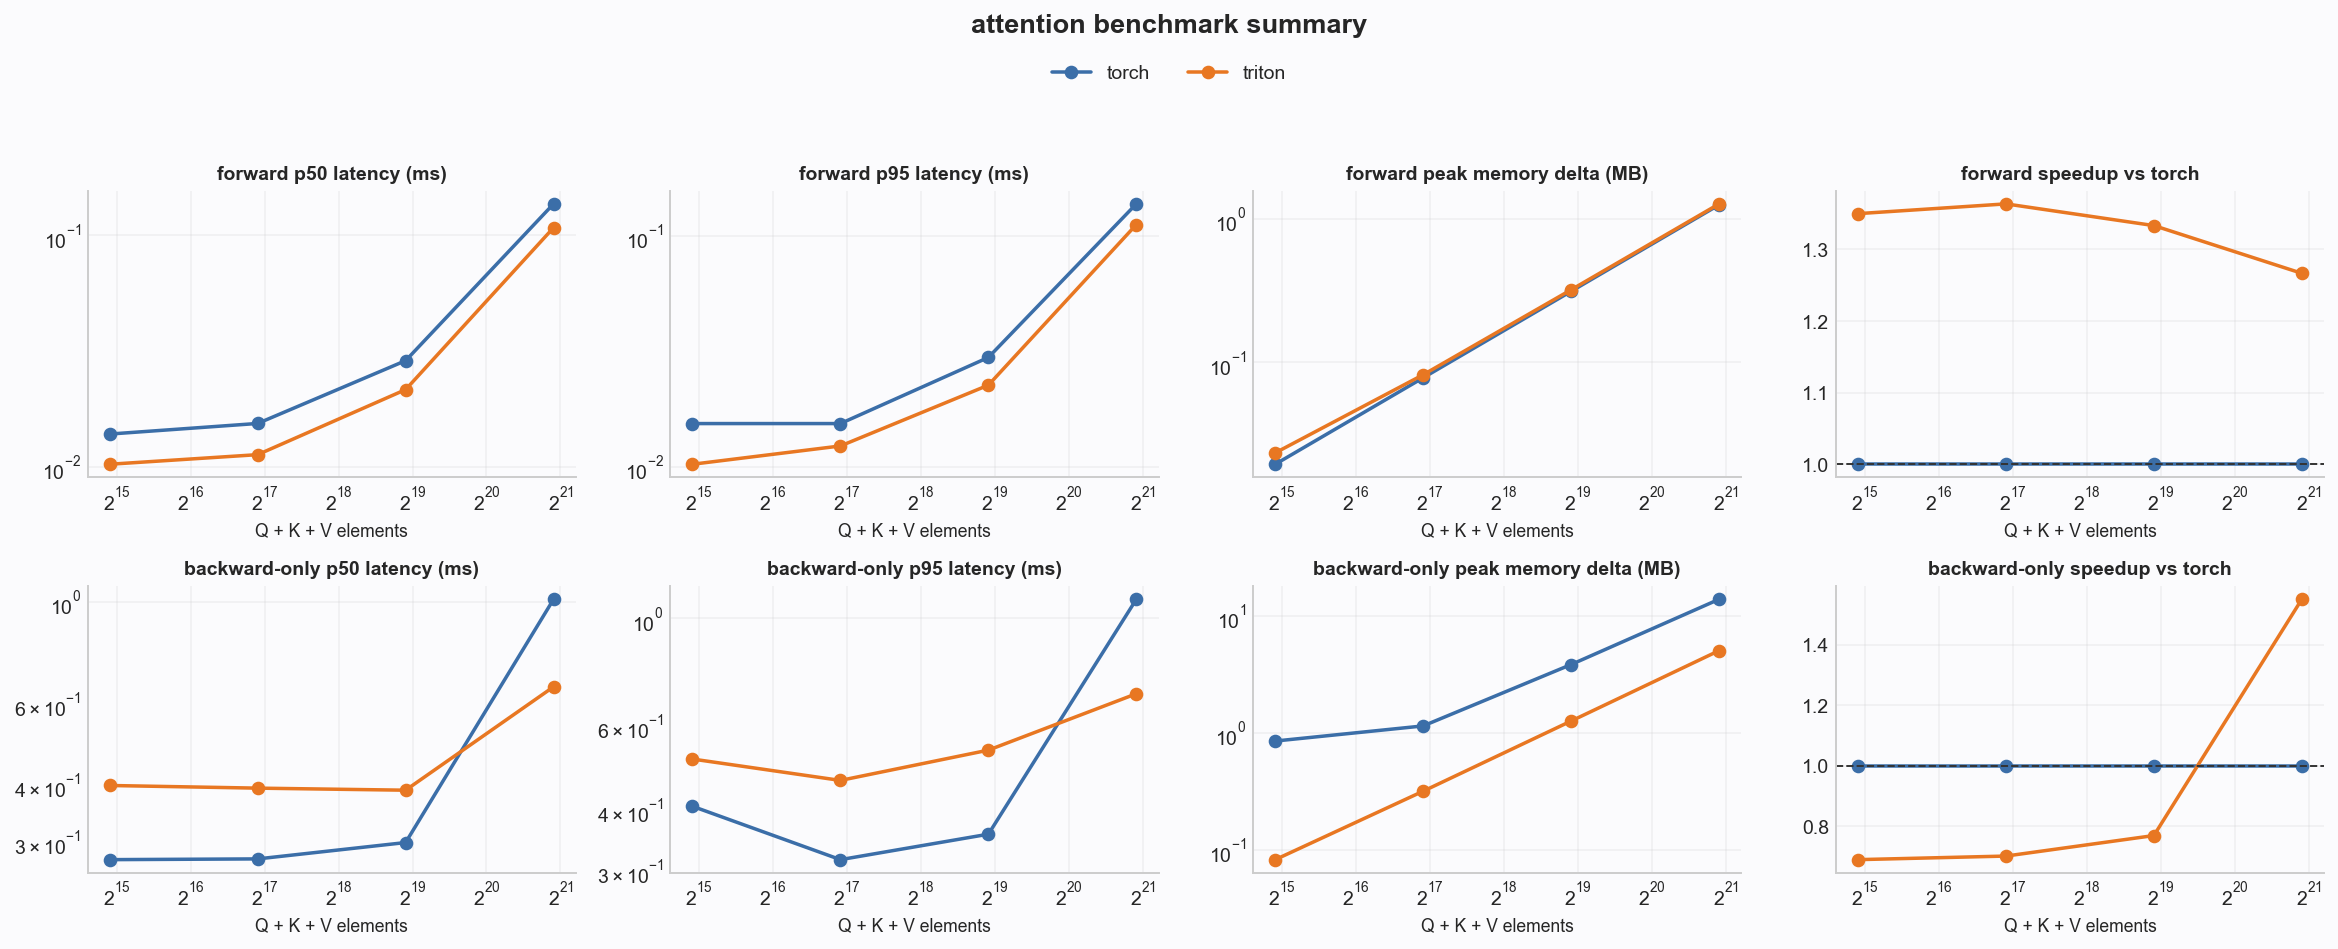

In [ ]:
import torch.nn.functional as F
from torch.profiler import ProfilerActivity
from minitrain.kernels.triton.flash_attention import flash_attention_autotune_kernels

PROVIDERS = ("torch", "triton")

ATTENTION_BATCH = 2
ATTENTION_HEADS = 4
ATTENTION_HEAD_DIM = 128
ATTENTION_SEQS = (1024, 1024*4, 1024*16, 1024*64)
ATTENTION_IS_CAUSAL = True
ATTENTION_DROPOUT_P = 0.0

SDPA_ATEN_BACKENDS = (
    ("aten::_scaled_dot_product_flash_attention", "flash_attention"),
    ("aten::_scaled_dot_product_efficient_attention", "memory_efficient_attention"),
    ("aten::_scaled_dot_product_cudnn_attention", "cudnn_attention"),
    ("aten::_scaled_dot_product_attention_math", "math"),
)


def detect_pytorch_sdpa_backend(q, k, v, *, is_causal, dropout_p):
    activities = [ProfilerActivity.CPU]
    if q.is_cuda:
        activities.append(ProfilerActivity.CUDA)
        torch.cuda.synchronize()

    with torch.profiler.profile(activities=activities) as prof:
        with torch.no_grad():
            F.scaled_dot_product_attention(
                q,
                k,
                v,
                is_causal=is_causal,
                dropout_p=dropout_p,
            )
        if q.is_cuda:
            torch.cuda.synchronize()

    event_keys = {event.key for event in prof.key_averages()}
    for aten_name, backend_name in SDPA_ATEN_BACKENDS:
        if aten_name in event_keys:
            return backend_name

    sdpa_events = sorted(
        key for key in event_keys if "scaled_dot_product" in key or "sdp" in key.lower()
    )
    return "unknown: " + ", ".join(sdpa_events[:6])


def attention_size(seq):
    return 3 * ATTENTION_BATCH * ATTENTION_HEADS * seq * ATTENTION_HEAD_DIM


def make_attention_case(size):
    seq = size // (3 * ATTENTION_BATCH * ATTENTION_HEADS * ATTENTION_HEAD_DIM)
    return BenchCase(
        tensors={
            "q": torch.randn(
                ATTENTION_BATCH,
                ATTENTION_HEADS,
                seq,
                ATTENTION_HEAD_DIM,
                device=DEVICE,
                dtype=DTYPE,
            ),
            "k": torch.randn(
                ATTENTION_BATCH,
                ATTENTION_HEADS,
                seq,
                ATTENTION_HEAD_DIM,
                device=DEVICE,
                dtype=DTYPE,
            ),
            "v": torch.randn(
                ATTENTION_BATCH,
                ATTENTION_HEADS,
                seq,
                ATTENTION_HEAD_DIM,
                device=DEVICE,
                dtype=DTYPE,
            ),
        },
        grad_names=("q", "k", "v"),
    )


def attention_forward(provider, tensors):
    backend = get_ops_backend(provider)
    return backend.attention(
        tensors["q"],
        tensors["k"],
        tensors["v"],
        is_causal=ATTENTION_IS_CAUSAL,
        dropout_p=ATTENTION_DROPOUT_P,
    )


def print_sdpa_backend_report(sizes):
    print("PyTorch SDPA backend selection:")
    print(f"  is_causal={ATTENTION_IS_CAUSAL}, dropout_p={ATTENTION_DROPOUT_P}")
    for size in sizes:
        case = make_attention_case(size)
        q, k, v = case.tensors["q"], case.tensors["k"], case.tensors["v"]
        backend = detect_pytorch_sdpa_backend(
            q,
            k,
            v,
            is_causal=ATTENTION_IS_CAUSAL,
            dropout_p=ATTENTION_DROPOUT_P,
        )
        print(f"  shape={tuple(q.shape)} -> {backend}")
        del case, q, k, v
        torch.cuda.empty_cache()


attention_sizes = [attention_size(seq) for seq in ATTENTION_SEQS]
print_sdpa_backend_report(attention_sizes)
attention_rows = run_kernel(
    "attention",
    attention_sizes,
    "Q + K + V elements",
    make_attention_case,
    attention_forward,
    autotune_kernels=flash_attention_autotune_kernels(),
    nsight_size=attention_size(128),
)

attention_summary = to_summary_dataframe(attention_rows)
attention_failures = attention_summary[attention_summary["status"] != "ok"]
if len(attention_failures):
    display(attention_failures[["provider", "size", "status", "error"]])

### FlashAttention (dropout)

Correctness uses the Triton-generated dropout mask on a small shape; benchmark rows below compare full-size PyTorch SDPA and Triton runtime/memory.


d:\anaconda\envs\llm\lib\site-packages\torch\autograd\graph.py:825: UserWarning: Attempting to run cuBLAS, but there was no current CUDA context! Attempting to set the primary context... (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\builder\windows\pytorch\aten\src\ATen\cuda\CublasHandlePool.cpp:135.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


Triton dropout correctness against explicit-mask PyTorch reference:


,status,dropout_p,keep_ratio
0,ok,0.25,0.749268


,check,correct,max_abs
0,fwd,True,0.003759
1,dq,False,2.270205
2,dk,False,2.987111
3,dv,False,3.994349


PyTorch SDPA backend selection:
  is_causal=True, dropout_p=0.25
  shape=(2, 4, 1024, 128) -> memory_efficient_attention
  shape=(2, 4, 4096, 128) -> memory_efficient_attention
  shape=(2, 4, 16384, 128) -> memory_efficient_attention
  shape=(2, 4, 65536, 128) -> memory_efficient_attention


,benchmark,provider,size,size_label,triton_kernel,BLOCK_M,BLOCK_N,num_warps,num_stages,num_ctas
0,attention_dropout,triton,3145728,Q + K + V elements,flash_attention_forward,128,32,8,3,1
1,attention_dropout,triton,3145728,Q + K + V elements,flash_attention_backward,128,128,8,3,1
2,attention_dropout,triton,12582912,Q + K + V elements,flash_attention_forward,64,32,4,2,1
3,attention_dropout,triton,12582912,Q + K + V elements,flash_attention_backward,128,128,8,3,1
4,attention_dropout,triton,50331648,Q + K + V elements,flash_attention_forward,128,32,8,3,1
5,attention_dropout,triton,50331648,Q + K + V elements,flash_attention_backward,128,128,8,3,1
6,attention_dropout,triton,201326592,Q + K + V elements,flash_attention_forward,128,64,8,3,1
7,attention_dropout,triton,201326592,Q + K + V elements,flash_attention_backward,128,128,8,3,1


,kernel,provider,size,status,fwd_correct,bwd_correct,fwd_p50_ms,fwd_p95_ms,fwd_peak_mem_mb,fwd_speedup,bwd_p50_ms,bwd_p95_ms,bwd_peak_mem_mb,bwd_speedup
0,attention_dropout,torch,3145728,ok,True,True,0.398336,0.399360,2.000000,1.000000,2.198496,2.495078,22.035645,1.000000
1,attention_dropout,triton,3145728,ok,True,False,0.367104,0.368998,2.031738,1.085077,1.665936,1.849498,8.031738,1.319676
2,attention_dropout,torch,12582912,ok,True,True,5.138944,5.763584,8.000000,1.000000,27.240448,27.870157,68.641113,1.000000
3,attention_dropout,triton,12582912,ok,True,False,4.188160,4.832665,8.125488,1.227017,13.740496,14.053888,32.125488,1.982494
4,attention_dropout,torch,50331648,ok,True,True,82.021378,82.021378,32.000000,1.000000,451.814926,454.680516,237.062988,1.000000
5,attention_dropout,triton,50331648,ok,True,False,66.622467,66.622467,32.500488,1.231137,205.072449,205.760174,128.500488,2.203197
6,attention_dropout,torch,201326592,ok,True,True,1301.943359,1301.943359,128.000000,1.000000,7126.921143,7266.093286,910.750488,1.000000
7,attention_dropout,triton,201326592,ok,True,False,1018.342407,1018.342407,130.000488,1.278493,3329.168945,3366.792871,514.000488,2.140751


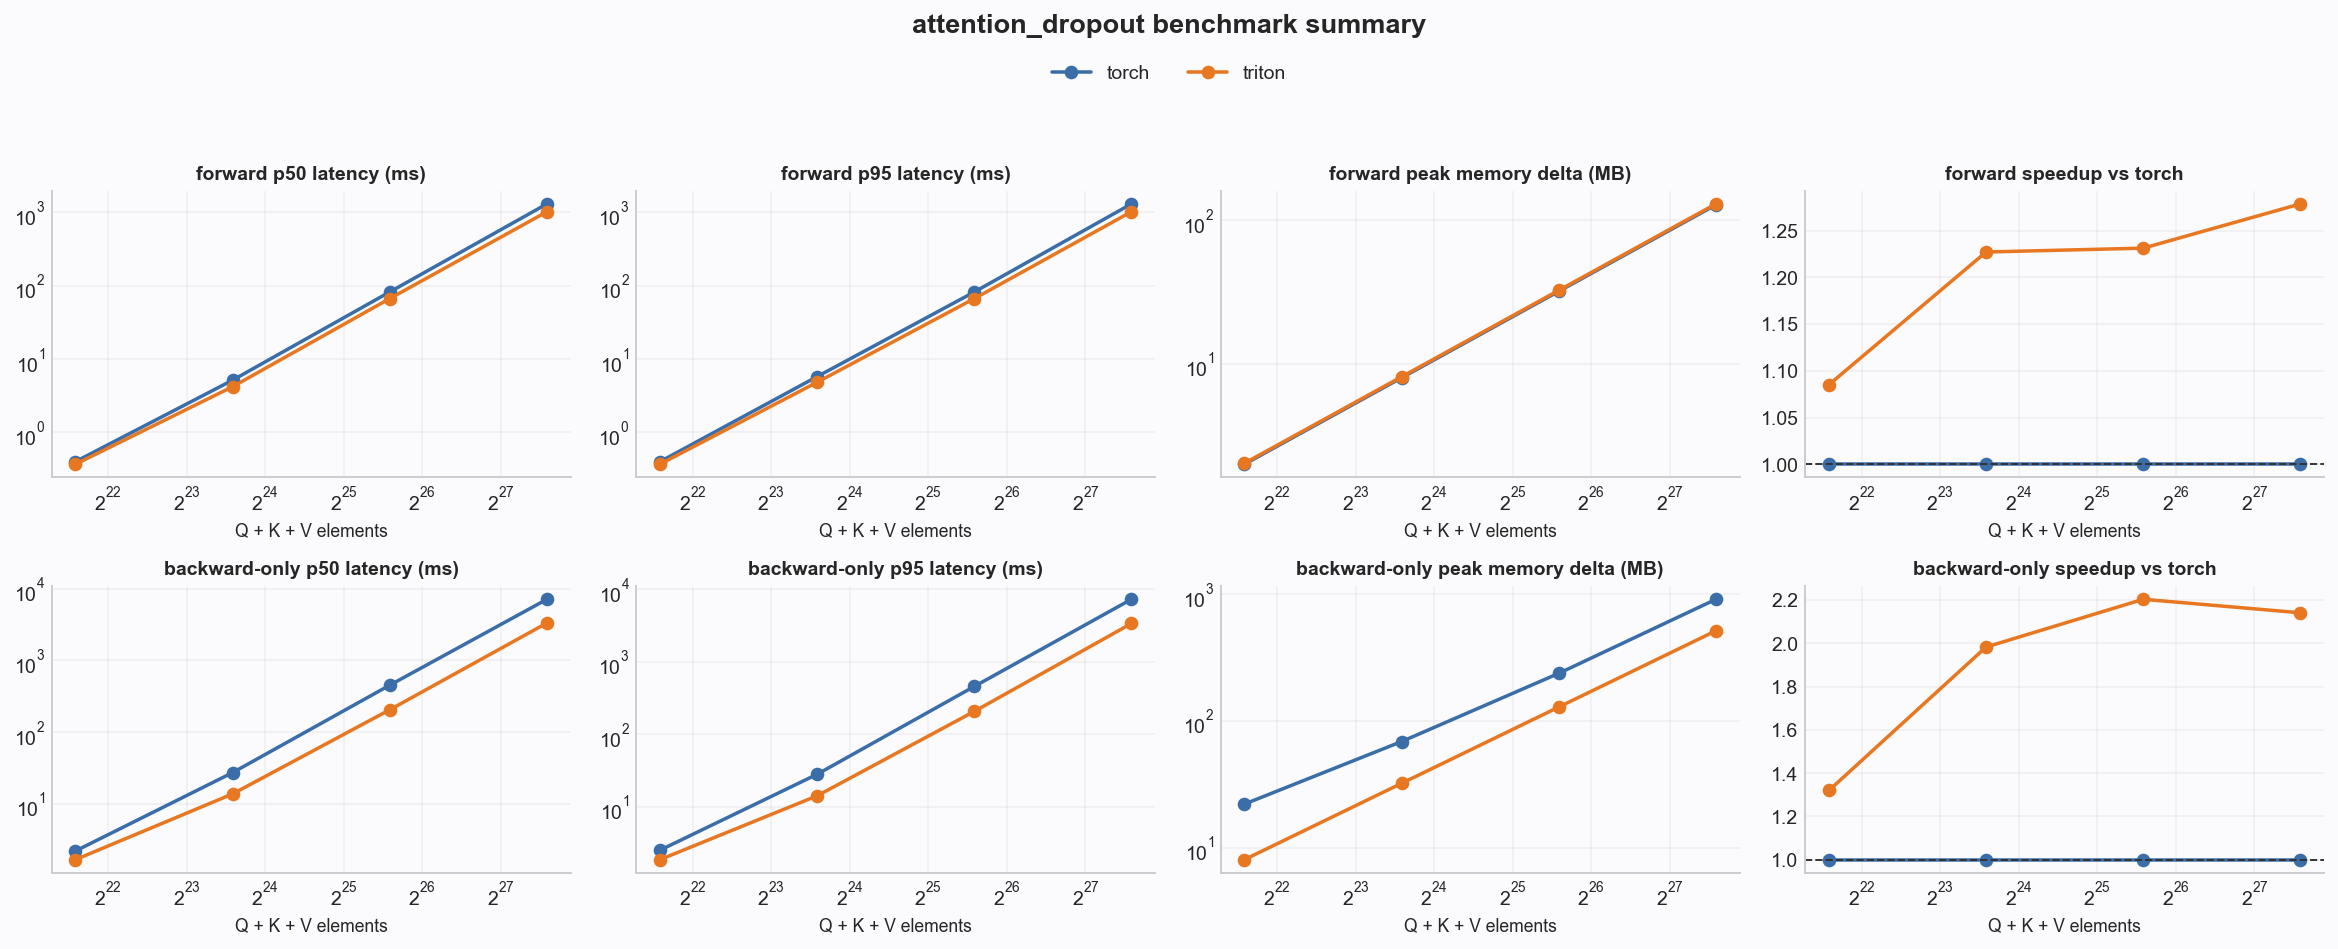

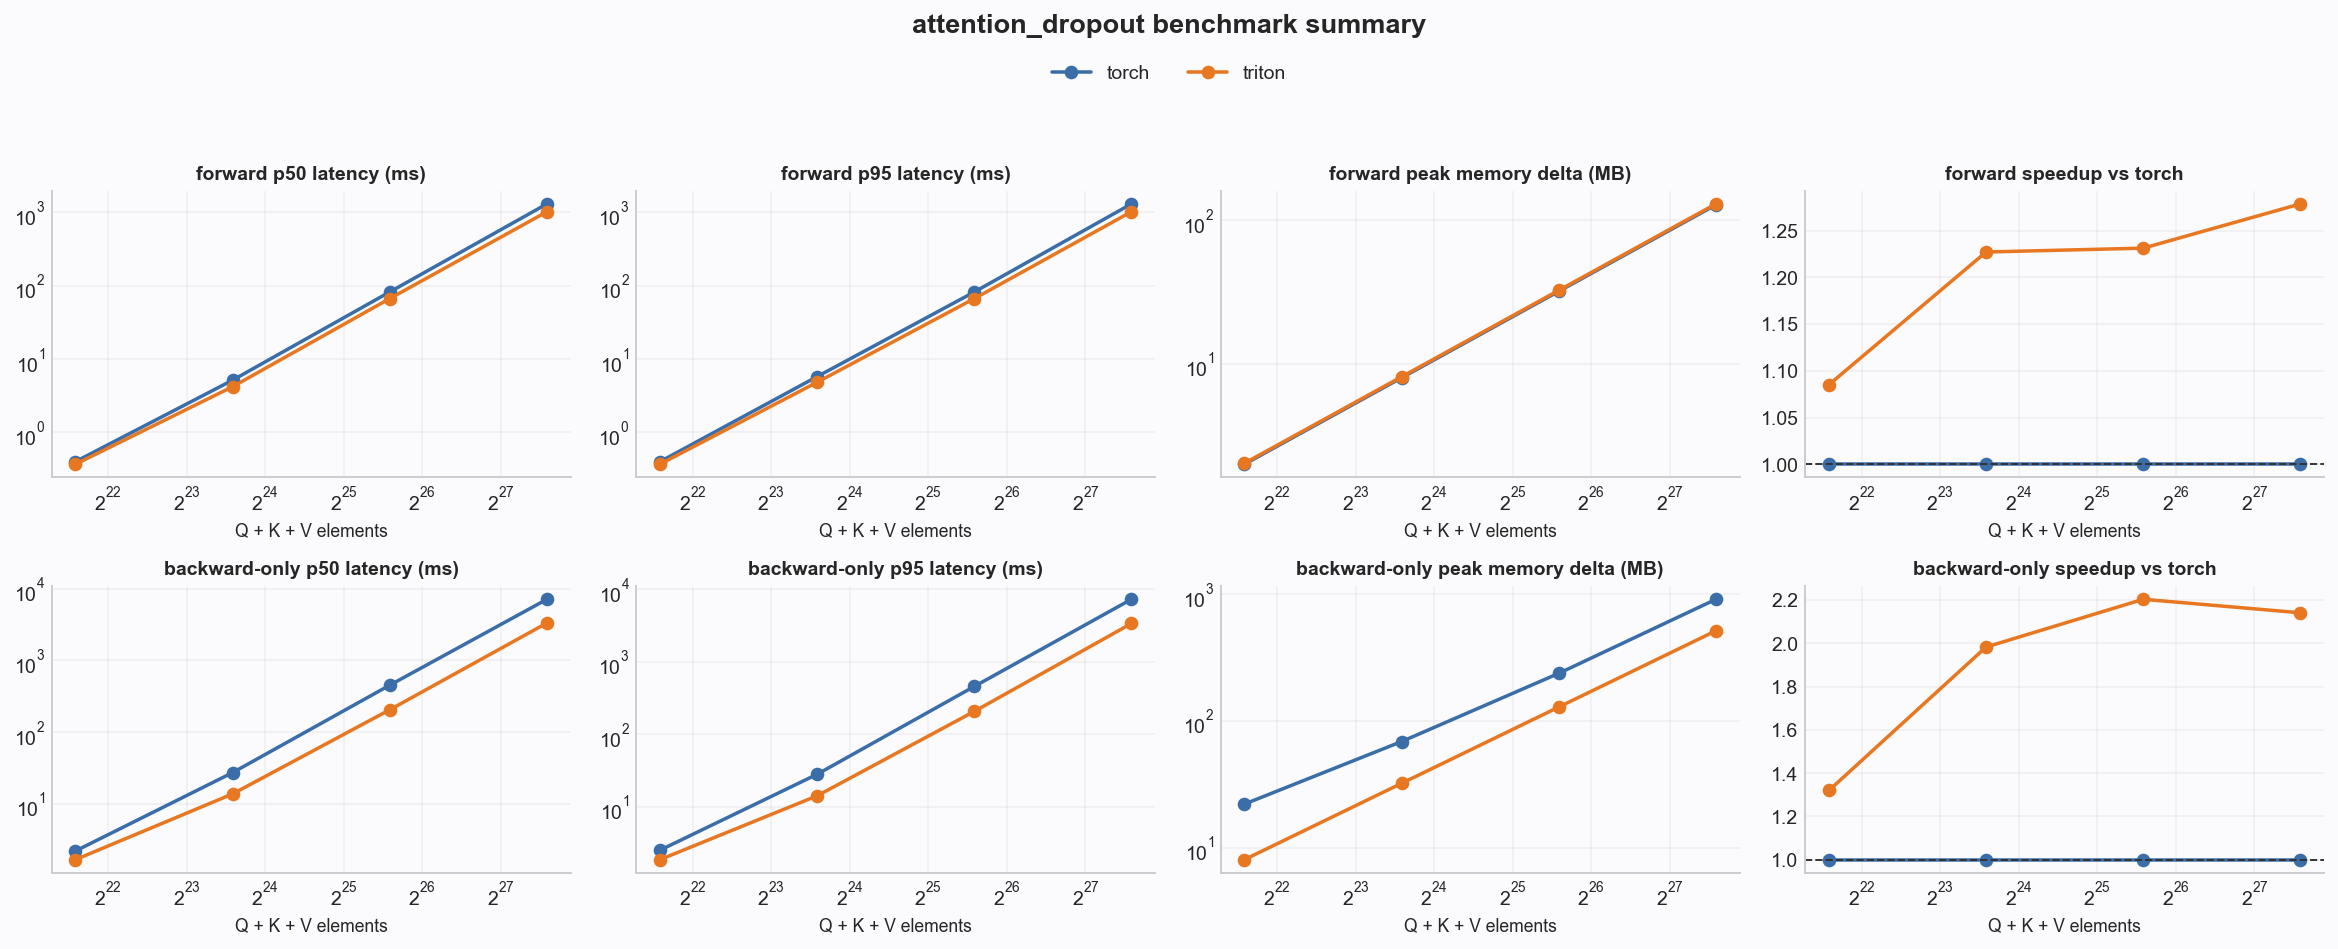

In [3]:

import math
import torch.nn.functional as F
from torch.profiler import ProfilerActivity

from minitrain.kernels.triton.flash_attention import flash_attention_backward
from minitrain.kernels.triton.flash_attention import flash_attention_autotune_kernels
from minitrain.kernels.triton.flash_attention import flash_attention_dropout_mask
from minitrain.kernels.triton.flash_attention import flash_attention_forward
from minitrain.kernels.triton.flash_attention import is_flash_attention_supported
from operator_bench_utils import benchmark_step, release_cache

PROVIDERS = ("torch", "triton")

ATTENTION_DROPOUT_BATCH = 2
ATTENTION_DROPOUT_HEADS = 4
ATTENTION_DROPOUT_HEAD_DIM = 128
ATTENTION_DROPOUT_SEQS = (1024, 1024*4, 1024*16, 1024*64)
ATTENTION_DROPOUT_IS_CAUSAL = True
ATTENTION_DROPOUT_P = 0.25

SDPA_ATEN_BACKENDS = (
    ("aten::_scaled_dot_product_flash_attention", "flash_attention"),
    ("aten::_scaled_dot_product_efficient_attention", "memory_efficient_attention"),
    ("aten::_scaled_dot_product_cudnn_attention", "cudnn_attention"),
    ("aten::_scaled_dot_product_attention_math", "math"),
)

def detect_pytorch_sdpa_backend(q, k, v, *, is_causal, dropout_p):
    activities = [ProfilerActivity.CPU]
    if q.is_cuda:
        activities.append(ProfilerActivity.CUDA)
        torch.cuda.synchronize()

    with torch.profiler.profile(activities=activities) as prof:
        with torch.no_grad():
            F.scaled_dot_product_attention(
                q,
                k,
                v,
                is_causal=is_causal,
                dropout_p=dropout_p,
            )
        if q.is_cuda:
            torch.cuda.synchronize()

    event_keys = {event.key for event in prof.key_averages()}
    for aten_name, backend_name in SDPA_ATEN_BACKENDS:
        if aten_name in event_keys:
            return backend_name

    sdpa_events = sorted(
        key for key in event_keys if "scaled_dot_product" in key or "sdp" in key.lower()
    )
    return "unknown: " + ", ".join(sdpa_events[:6])

def make_attention_dropout_case(size):
    seq = size // (3 * ATTENTION_DROPOUT_BATCH * ATTENTION_DROPOUT_HEADS * ATTENTION_DROPOUT_HEAD_DIM)
    return BenchCase(
        tensors={
            "q": torch.randn(ATTENTION_DROPOUT_BATCH, ATTENTION_DROPOUT_HEADS, seq, ATTENTION_DROPOUT_HEAD_DIM, device=DEVICE, dtype=DTYPE),
            "k": torch.randn(ATTENTION_DROPOUT_BATCH, ATTENTION_DROPOUT_HEADS, seq, ATTENTION_DROPOUT_HEAD_DIM, device=DEVICE, dtype=DTYPE),
            "v": torch.randn(ATTENTION_DROPOUT_BATCH, ATTENTION_DROPOUT_HEADS, seq, ATTENTION_DROPOUT_HEAD_DIM, device=DEVICE, dtype=DTYPE),
        },
        grad_names=("q", "k", "v"),
    )


def attention_dropout_forward(provider, tensors):
    return get_ops_backend(provider).attention(
        tensors["q"],
        tensors["k"],
        tensors["v"],
        is_causal=ATTENTION_DROPOUT_IS_CAUSAL,
        dropout_p=ATTENTION_DROPOUT_P,
    )


def attention_dropout_correctness():
    release_cache()
    try:
        batch, heads, seq, head_dim = 1, 2, 64, 32
        dropout_p = ATTENTION_DROPOUT_P
        dtype = torch.float32

        q = torch.randn(batch, heads, seq, head_dim, device=DEVICE, dtype=dtype)
        k = torch.randn(batch, heads, seq, head_dim, device=DEVICE, dtype=dtype)
        v = torch.randn(batch, heads, seq, head_dim, device=DEVICE, dtype=dtype)
        if not is_flash_attention_supported(q, k, v, dropout_p=dropout_p):
            return {"status": "unsupported"}

        seed = torch.tensor(1234567, device=DEVICE, dtype=torch.int32)
        do = torch.randn_like(q)
        torch.cuda.synchronize()

        out, lse, _, softmax_scale = flash_attention_forward(
            q,
            k,
            v,
            is_causal=ATTENTION_DROPOUT_IS_CAUSAL,
            dropout_p=dropout_p,
            dropout_seed=seed,
        )
        keep_mask = flash_attention_dropout_mask(
            batch,
            heads,
            seq,
            seq,
            device=DEVICE,
            dropout_p=dropout_p,
            dropout_seed=seed,
        )
        torch.cuda.synchronize()

        q_ref = q.detach().clone().requires_grad_(True)
        k_ref = k.detach().clone().requires_grad_(True)
        v_ref = v.detach().clone().requires_grad_(True)
        scores = torch.matmul(q_ref, k_ref.transpose(-1, -2)) / math.sqrt(head_dim)
        if ATTENTION_DROPOUT_IS_CAUSAL:
            idx = torch.arange(seq, device=DEVICE)
            scores = scores.masked_fill(idx[:, None] < idx[None, :], float("-inf"))
        probs = torch.softmax(scores, dim=-1)
        ref = torch.matmul(probs * keep_mask / (1.0 - dropout_p), v_ref)
        ref.backward(do)
        torch.cuda.synchronize()

        dq, dk, dv = flash_attention_backward(
            do,
            q,
            k,
            v,
            out,
            lse,
            seed,
            is_causal=ATTENTION_DROPOUT_IS_CAUSAL,
            dropout_p=dropout_p,
            softmax_scale=softmax_scale,
        )
        torch.cuda.synchronize()

        pairs = {
            "fwd": (out, ref),
            "dq": (dq, q_ref.grad),
            "dk": (dk, k_ref.grad),
            "dv": (dv, v_ref.grad),
        }
        stats = {"status": "ok", "keep_ratio": float(keep_mask.float().mean().item())}
        for name, (actual, expected) in pairs.items():
            actual, expected = actual.float(), expected.float()
            abs_err = (actual - expected).abs()
            stats[f"{name}_max_abs"] = float(abs_err.max().item())
            stats[f"{name}_correct"] = bool(torch.allclose(actual, expected, atol=3e-2, rtol=3e-2))
        return stats
    finally:
        release_cache()

dropout_correctness = attention_dropout_correctness()
print("Triton dropout correctness against explicit-mask PyTorch reference:")
correctness_summary = [{
    "status": dropout_correctness.get("status"),
    "dropout_p": ATTENTION_DROPOUT_P,
    "keep_ratio": dropout_correctness.get("keep_ratio"),
}]
correctness_rows = [
    {
        "check": name,
        "correct": dropout_correctness.get(f"{name}_correct"),
        "max_abs": dropout_correctness.get(f"{name}_max_abs"),
    }
    for name in ("fwd", "dq", "dk", "dv")
]
try:
    import pandas as pd

    display(pd.DataFrame(correctness_summary))
    display(pd.DataFrame(correctness_rows))
except ImportError:
    display(correctness_summary)
    display(correctness_rows)

attention_dropout_sizes = [
    3 * ATTENTION_DROPOUT_BATCH * ATTENTION_DROPOUT_HEADS * seq * ATTENTION_DROPOUT_HEAD_DIM
    for seq in ATTENTION_DROPOUT_SEQS
]
register_nsight_kernel(
    "attention_dropout",
    make_attention_dropout_case,
    attention_dropout_forward,
    default_size=(
        3 * ATTENTION_DROPOUT_BATCH * ATTENTION_DROPOUT_HEADS
        * 128 * ATTENTION_DROPOUT_HEAD_DIM
    ),
)

print("PyTorch SDPA backend selection:")
print(f"  is_causal={ATTENTION_DROPOUT_IS_CAUSAL}, dropout_p={ATTENTION_DROPOUT_P}")
for size in attention_dropout_sizes:
    case = make_attention_dropout_case(size)
    q, k, v = case.tensors["q"], case.tensors["k"], case.tensors["v"]
    backend = detect_pytorch_sdpa_backend(q, k, v, is_causal=ATTENTION_DROPOUT_IS_CAUSAL, dropout_p=ATTENTION_DROPOUT_P)
    print(f"  shape={tuple(q.shape)} -> {backend}")
    case.tensors.clear()
    release_cache()

attention_dropout_rows = []
for size in attention_dropout_sizes:
    torch_fwd_p50 = None
    torch_bwd_p50 = None
    for provider in PROVIDERS:
        row = {
            "kernel": "attention_dropout",
            "provider": provider,
            "size": size,
            "size_label": "Q + K + V elements",
            "status": "ok",
            "fwd_correct": provider == "torch" or dropout_correctness.get("fwd_correct", False),
            "bwd_correct": provider == "torch" or all(dropout_correctness.get(f"{name}_correct", False) for name in ("dq", "dk", "dv")),
        }
        try:
            row.update(benchmark_step(make_attention_dropout_case, size, provider, attention_dropout_forward, mode="fwd", warmup_ms=WARMUP_MS, rep_ms=REP_MS))
            row.update(benchmark_step(make_attention_dropout_case, size, provider, attention_dropout_forward, mode="bwd", warmup_ms=WARMUP_MS, rep_ms=REP_MS))
            if provider == "triton":
                row["triton_best_configs"] = collect_triton_best_configs(
                    flash_attention_autotune_kernels()
                )
        except Exception as exc:
            row.update({"status": "unavailable", "error": f"{type(exc).__name__}: {exc}"})
            row.update({name: math.nan for name in METRICS})

        if provider == "torch" and row["status"] == "ok":
            torch_fwd_p50 = row["fwd_p50_ms"]
            torch_bwd_p50 = row["bwd_p50_ms"]
            row["fwd_speedup"] = 1.0
            row["bwd_speedup"] = 1.0
        else:
            row["fwd_speedup"] = math.nan if torch_fwd_p50 in (None, 0.0) else torch_fwd_p50 / row["fwd_p50_ms"]
            row["bwd_speedup"] = math.nan if torch_bwd_p50 in (None, 0.0) else torch_bwd_p50 / row["bwd_p50_ms"]
        attention_dropout_rows.append(row)
    release_cache()

display_triton_config_summary(attention_dropout_rows)
display(to_summary_dataframe(attention_dropout_rows))
plot_kernel_grid(attention_dropout_rows, metrics=METRICS, save_path=FIG_DIR / "attention_dropout_summary.png")